this notebook trains model without  performing oversmapling for underrepresented classes

In [23]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score
)

In [24]:
DATA_DIR=Path('processed_data')
CLASS_NAMES=['no_dr','mild','moderate','severe','proliferative_dr']

NUM_CLASSES=len(CLASS_NAMES)
IMAGE_SIZE=300
BATCH_SIZE=8
NUM_WORKERS=0

INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-4
WEIGHT_DECAY = 1e-4

NUM_EPOCHS = 20
WARMUP_EPOCHS = 3      
PATIENCE = 5


In [25]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("torch version: " , torch.__version__)
print("torchcison version: " , torchvision.__version__)
print("devide used:" , device)


if torch.cuda.is_available():
    print('GPU: ',torch.cuda.get_device_name(0))

torch version:  2.6.0+cu124
torchcison version:  0.21.0+cu124
devide used: cuda
GPU:  NVIDIA GeForce RTX 3050 Laptop GPU


In [26]:
SEED=42
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory: 4.0 GB


In [27]:

records = []

valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

for label, class_name in enumerate(CLASS_NAMES):

    class_dir = DATA_DIR / class_name

    if not class_dir.exists():

        print(
            f"WARNING: Missing folder -> {class_dir}"
        )

        continue

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() in valid_extensions:

            records.append({

                "image_path": str(image_path),

                "class_name": class_name,

                "label": label

            })


df = pd.DataFrame(records)

print("Total processed images:", len(df))

print("\nClass distribution:")

print(
    df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

Total processed images: 4122

Class distribution:
class_name
no_dr               1935
mild                 393
moderate            1156
severe               278
proliferative_dr     360
Name: count, dtype: int64


In [28]:

def file_hash(path):

    hasher = hashlib.md5()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(8192),
            b""
        ):

            hasher.update(chunk)

    return hasher.hexdigest()


df["hash"] = df["image_path"].apply(file_hash)

duplicate_rows = df[
    df.duplicated(
        "hash",
        keep=False
    )
].sort_values("hash")

print(
    "Duplicate files:",
    len(duplicate_rows)
)

print(
    "Duplicate groups:",
    duplicate_rows["hash"].nunique()
)

Duplicate files: 271
Duplicate groups: 133


In [29]:
df=(df.drop_duplicates(subset='hash', keep='first').reset_index(drop=True))
print(
    "Images after deduplication:",
    len(df)
)

print("\nClass distribution after deduplication:")

print(
    df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

Images after deduplication: 3984

Class distribution after deduplication:
class_name
no_dr               1929
mild                 364
moderate            1093
severe               264
proliferative_dr     334
Name: count, dtype: int64


In [30]:
train_df,val_df=train_test_split(df,test_size=0.2,stratify=df['label'],random_state=SEED)

train_df=train_df.reset_index(drop=True)
val_df=val_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training images: 3187
Validation images: 797


In [31]:

split_check = pd.DataFrame({

    "Train":
        train_df["class_name"].value_counts(),

    "Validation":
        val_df["class_name"].value_counts()

}).reindex(CLASS_NAMES)

split_check["Train %"] = (
    split_check["Train"]
    / len(train_df)
    * 100
)

split_check["Validation %"] = (
    split_check["Validation"]
    / len(val_df)
    * 100
)

display(
    split_check.round(2)
)

,Train,Validation,Train %,Validation %
class_name,,,,
no_dr,1543,386,48.42,48.43
mild,291,73,9.13,9.16
moderate,875,218,27.46,27.35
severe,211,53,6.62,6.65
proliferative_dr,267,67,8.38,8.41


In [32]:
train_df

,image_path,class_name,label,hash
0,processed_data\moderate\aptos_4da6e2089d57.png,moderate,2,eaad7808a956e15a57d934f33de29d84
1,processed_data\proliferative_dr\aptos_bdff5d8b...,proliferative_dr,4,bede42da0b2e9e7a60cc97de32496fa7
2,processed_data\no_dr\aptos_e03a74e7d74f.png,no_dr,0,dcfba0e0bebecd74bdab34e0128e83bb
3,processed_data\no_dr\aptos_1df1530b9b8d.png,no_dr,0,f2d0c776bc89dda9efd9588cc6b445af
4,processed_data\no_dr\idrid_IDRiD_267.jpg,no_dr,0,b0a329f3c2ac3c12dd182e46d767441a
...,...,...,...,...
3182,processed_data\no_dr\aptos_9e2a8135f471.png,no_dr,0,04ea219ca2263711ef870894264cb09e
3183,processed_data\moderate\aptos_77f69c7ff324.png,moderate,2,3f086570b4bfdad460926758cd3f43a2
3184,processed_data\no_dr\aptos_4c5ab774a381.png,no_dr,0,ae3776c6fadebbe92021f0e522b3b668
3185,processed_data\moderate\aptos_a9c7b83caf81.png,moderate,2,3e5fdf8ef7e05099d0cca9edb006b38c


In [33]:


def calculate_mean_std(dataframe):

    channel_sum = torch.zeros(3)

    channel_squared_sum = torch.zeros(3)

    total_pixels = 0


    for path in dataframe["image_path"]:

        image = Image.open(path).convert("RGB")

        image = np.asarray(
            image,
            dtype=np.float32
        ) / 255.0

        image = torch.from_numpy(
            image
        ).permute(2, 0, 1)


        pixels = (
            image.shape[1]
            *
            image.shape[2]
        )


        channel_sum += image.sum(
            dim=(1, 2)
        )

        channel_squared_sum += (
            image ** 2
        ).sum(
            dim=(1, 2)
        )


        total_pixels += pixels


    mean = (
        channel_sum /
        total_pixels
    )


    std = torch.sqrt(

        (
            channel_squared_sum /
            total_pixels
        )
        -
        mean ** 2

    )


    return (
        mean.tolist(),
        std.tolist()
    )


TRAIN_MEAN, TRAIN_STD = calculate_mean_std(
    train_df
)


print("Training mean:")
print(TRAIN_MEAN)

print("\nTraining std:")
print(TRAIN_STD)

Training mean:
[0.5023148655891418, 0.5012983679771423, 0.5017524361610413]

Training std:
[0.15819305181503296, 0.13094566762447357, 0.06753876060247421]


In [39]:
class DRDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label

In [40]:
train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    ])

In [41]:
train_dataset = DRDataset(
    train_df,
    transform=train_transform
)

val_dataset = DRDataset(
    val_df,
    transform=val_transform
)

In [42]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

In [43]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Labels:", labels)

Images: torch.Size([8, 3, 300, 300])
Labels: torch.Size([8])
Labels: tensor([0, 2, 0, 0, 0, 0, 2, 2])


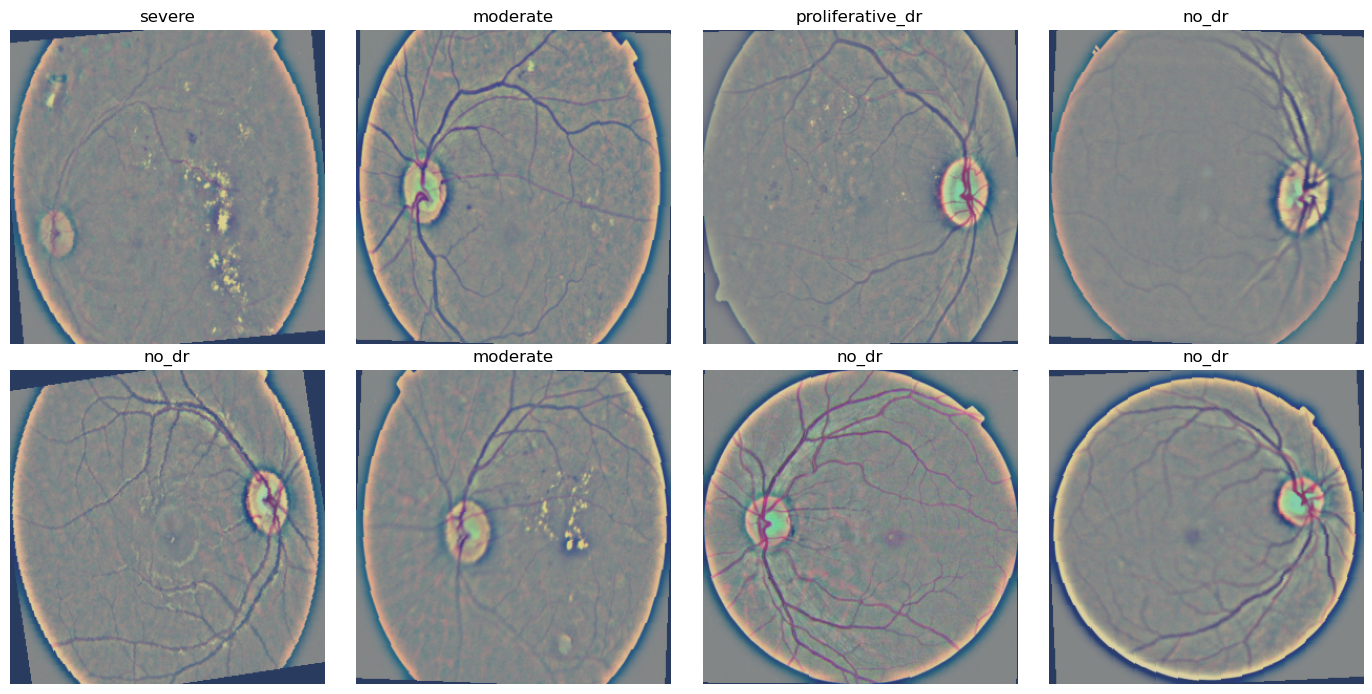

In [51]:
images, labels = next(iter(train_loader))

mean = torch.tensor(
[0.5023148655891418, 0.5012983679771423, 0.5017524361610413]
).view(3, 1, 1)

std = torch.tensor(
    [0.15819305181503296, 0.13094566762447357, 0.06753876060247421]
).view(3, 1, 1)

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 7)
)

for i, ax in enumerate(axes.flat):

    img = images[i] * std + mean
    img = torch.clamp(img, 0, 1)

    ax.imshow(
        img.permute(1, 2, 0)
    )

    ax.set_title(
        CLASS_NAMES[labels[i].item()]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()